# Predicting Band Gaps of SnSe-Based Materials from Composition

**FDP: Machine Learning for Materials and Metallurgical Engineering | 13–18 July 2026**

Capstone project notebook: queries the Materials Project for Sn-Se-based compounds, featurizes them with matminer (Magpie composition descriptors), and trains classification (metal vs. insulator) and regression (band gap) models with 5-fold cross-validation.

## 1. Problem Statement

Single-crystal SnSe is one of the best-performing thermoelectric materials discovered in the last decade, and its narrow, doping-tunable band gap is central to its performance. Materials scientists routinely explore doping and alloying SnSe (with Pb, Ge, S, Te, Ag, Na, halides, and others) to engineer this gap — traditionally guided by expensive DFT calculations or trial-and-error synthesis.

**Question:** can a composition-only machine learning model predict whether a Sn-Se-based compound is a metal or an insulator, and if an insulator, predict its band gap — using only elemental composition, without any DFT calculation or crystal structure input? This would let researchers rapidly triage candidate dopants/alloys before committing computational or experimental resources.

## 2. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
# Figures get embedded into fixed-size report/slide image slots and shrunk in the
# process, so source fonts are set larger than matplotlib defaults (per presentation
# typography guidance: axis labels 18-24pt, ticks 16-20pt, titles 24-32pt at display size).
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

/home/shahi/miniforge3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Dataset

**Source:** The Materials Project (materialsproject.org), queried live via the `mp-api` Python client for all compounds containing both Sn and Se (the SnSe binary system plus any ternary/quaternary/quinary doped or alloyed derivative — e.g. Sn-Se-Pb, Sn-Se-S, Sn-Se-Ag).

Requires a free API key (https://next-gen.materialsproject.org/api) set as the `MP_API_KEY` environment variable before running this notebook.

In [2]:
from mp_api.client import MPRester

api_key = os.environ["MP_API_KEY"]

with MPRester(api_key=api_key) as mpr:
    docs = mpr.materials.summary.search(
        elements=["Sn", "Se"],
        num_elements=(2, 7),
        fields=["material_id", "formula_pretty", "band_gap"],
    )

df = pd.DataFrame([d.model_dump() for d in docs])
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Retrieving SummaryDoc documents:   0%|          | 0/220 [00:00<?, ?it/s]

Retrieving SummaryDoc documents: 100%|██████████| 220/220 [00:00<00:00, 6031025.36it/s]

Shape: 220 rows, 5 columns


,formula_pretty,material_id,band_gap,fields_not_requested,unavailable_fields
0,CsSnSe3,mp-aaadjtde,1.190884,"[universal_anisotropy, phonon_IDs, e_ij_max, b...",[]
1,Ce2SnSe4,mp-aaacfgsm,0.000000,"[universal_anisotropy, phonon_IDs, e_ij_max, b...",[]
2,Tl2SnHgSe4,mp-aaacjjro,0.787900,"[universal_anisotropy, phonon_IDs, e_ij_max, b...",[]
3,ZnCu2SnSe4,mp-aaacjkaw,0.000000,"[universal_anisotropy, phonon_IDs, e_ij_max, b...",[]
4,K2CdSnSe4,mp-aaacjlcv,1.672100,"[universal_anisotropy, phonon_IDs, e_ij_max, b...",[]


## 4. Exploratory Data Analysis

Before modeling anything: are there missing or duplicate entries? What's the spread of the target (band gap)? How balanced are metals vs. insulators?

In [3]:
df_clean = df.dropna(subset=["formula_pretty", "band_gap"]).drop_duplicates(subset="formula_pretty").copy()
print(f"{len(df)} raw entries -> {len(df_clean)} after removing duplicates/missing band_gap")
df_clean["band_gap"].describe()

220 raw entries -> 192 after removing duplicates/missing band_gap


count    192.000000
mean       0.726585
std        0.748129
min        0.000000
25%        0.000000
50%        0.597523
75%        1.260027
max        4.432000
Name: band_gap, dtype: float64

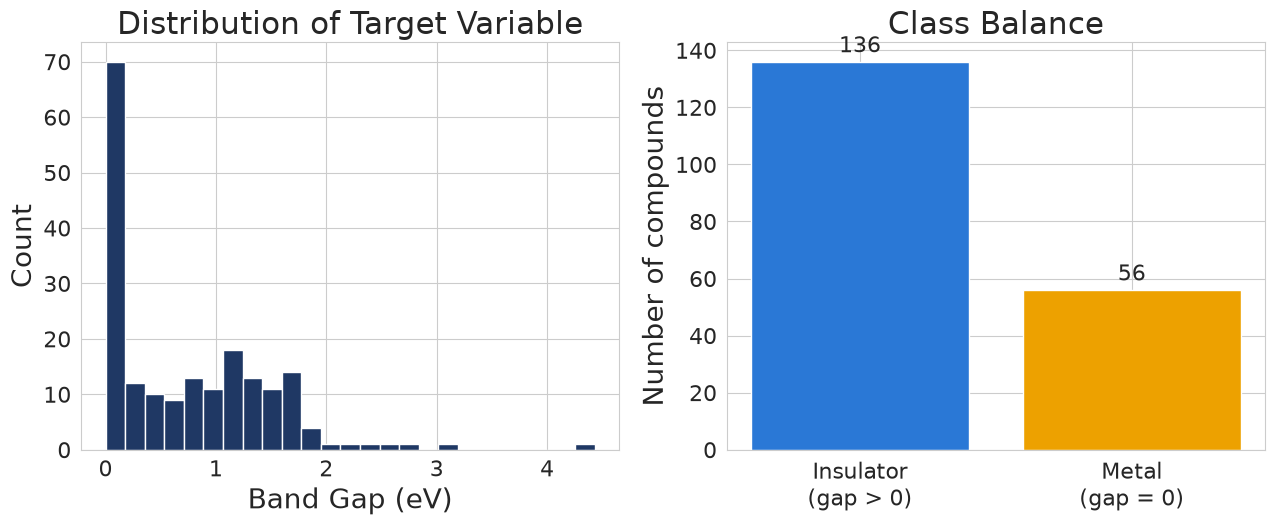

In [4]:
df_clean["is_metal"] = (df_clean["band_gap"] == 0).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].hist(df_clean["band_gap"], bins=25, color="#1F3864", edgecolor="white")
ax[0].set_xlabel("Band Gap (eV)")
ax[0].set_ylabel("Count")
ax[0].set_title("Distribution of Target Variable")

counts = df_clean["is_metal"].value_counts().sort_index()
labels = ["Insulator\n(gap > 0)", "Metal\n(gap = 0)"]
values = [counts.get(0, 0), counts.get(1, 0)]
bars = ax[1].bar(labels, values, color=["#2a78d6", "#eda100"])
ax[1].bar_label(bars, padding=3, fontsize=16)
ax[1].set_ylabel("Number of compounds")
ax[1].set_title("Class Balance")
plt.tight_layout()
plt.savefig("figures/fig_eda.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Preprocessing

Each compound's formula is converted to a `pymatgen.Composition` object and featurized with matminer's `ElementProperty.from_preset("magpie")`, producing composition-derived descriptors (statistics of electronegativity, atomic radius, valence electron counts, melting point, etc.) — no crystal-structure information is used, only chemical formula.

In [5]:
df_clean["composition"] = df_clean["formula_pretty"].apply(Composition)

featurizer = ElementProperty.from_preset("magpie")
df_feat = featurizer.featurize_dataframe(df_clean, col_id="composition", ignore_errors=True)
feature_cols = featurizer.feature_labels()
df_feat = df_feat.dropna(subset=feature_cols)

print(f"Features: {len(feature_cols)} columns, {df_feat.shape[0]} rows")
print(f"Target range: {df_feat['band_gap'].min():.2f} to {df_feat['band_gap'].max():.2f} eV")

ElementProperty:   0%|          | 0/192 [00:00<?, ?it/s]

ElementProperty:  68%|██████▊   | 130/192 [00:00<00:00, 1298.87it/s]

ElementProperty: 100%|██████████| 192/192 [00:00<00:00, 1815.61it/s]

Features: 132 columns, 192 rows
Target range: 0.00 to 4.43 eV


## 6. Train/Test Split

Two modeling stages follow (classification, then regression on insulators only), so there are two splits — the main stratified split below is for classification. The regression split is created later in Section 7 once the insulator subset is defined.

In [6]:
X = df_feat[feature_cols]
y_class = df_feat["is_metal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 153 rows | Test: 39 rows


## 7. Model Training

**Stage A — Classification:** Logistic Regression vs. Random Forest (300 trees), predicting metal (`band_gap == 0`) vs. insulator (`band_gap > 0`).

**Stage B — Regression:** Random Forest (300 trees) on the insulator subset only, predicting the band gap value (eV).

In [7]:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

rf_clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_clf.fit(X_train, y_train)

insulators = df_feat[df_feat["band_gap"] > 0]
X_ins = insulators[feature_cols]
y_ins = insulators["band_gap"]
Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_ins, y_ins, test_size=0.2, random_state=RANDOM_STATE)

rf_reg = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
rf_reg.fit(Xi_train, yi_train)

print("Models trained.")

Models trained.


## 8. Evaluation

Because the dataset is small (a few hundred compounds) relative to the 130+ features, a single train/test split gives a noisy estimate. We report 5-fold cross-validation (mean ± std) as the primary metric for both stages, alongside the single-split result for reference.

In [8]:
logreg_acc = accuracy_score(y_test, logreg.predict(X_test_scaled))
rf_clf_acc = accuracy_score(y_test, rf_clf.predict(X_test))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_scaled_full = StandardScaler().fit_transform(X)
logreg_cv = cross_val_score(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), X_scaled_full, y_class, cv=skf)
rf_cv = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE), X, y_class, cv=skf)

print("--- Classification (metal vs. insulator) ---")
print(f"Logistic Regression: single-split acc={logreg_acc:.3f} | 5-fold CV acc={logreg_cv.mean():.3f} +/- {logreg_cv.std():.3f}")
print(f"Random Forest      : single-split acc={rf_clf_acc:.3f} | 5-fold CV acc={rf_cv.mean():.3f} +/- {rf_cv.std():.3f}")
print("\nRandom Forest confusion matrix (rows=true [insulator, metal], cols=predicted):")
print(confusion_matrix(y_test, rf_clf.predict(X_test)))

--- Classification (metal vs. insulator) ---
Logistic Regression: single-split acc=0.744 | 5-fold CV acc=0.781 +/- 0.065
Random Forest      : single-split acc=0.846 | 5-fold CV acc=0.802 +/- 0.037

Random Forest confusion matrix (rows=true [insulator, metal], cols=predicted):
[[26  2]
 [ 4  7]]


--- Regression (band gap, insulators only) ---
Single-split: R²=0.279 | RMSE=0.626 eV | MAE=0.414 eV
5-fold CV   : MAE=0.357 +/- 0.072 eV | R²=0.401 +/- 0.168


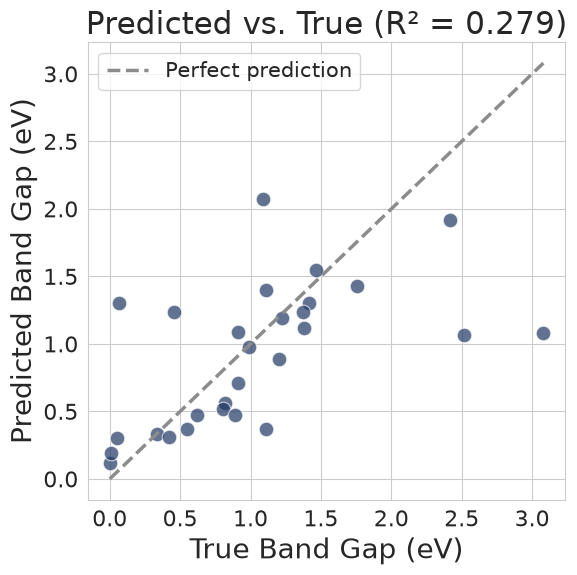

In [9]:
y_pred = rf_reg.predict(Xi_test)
r2 = r2_score(yi_test, y_pred)
rmse = np.sqrt(mean_squared_error(yi_test, y_pred))
mae = mean_absolute_error(yi_test, y_pred)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mae_cv = -cross_val_score(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE), X_ins, y_ins, cv=kf, scoring="neg_mean_absolute_error")
r2_cv = cross_val_score(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE), X_ins, y_ins, cv=kf, scoring="r2")

print("--- Regression (band gap, insulators only) ---")
print(f"Single-split: R²={r2:.3f} | RMSE={rmse:.3f} eV | MAE={mae:.3f} eV")
print(f"5-fold CV   : MAE={mae_cv.mean():.3f} +/- {mae_cv.std():.3f} eV | R²={r2_cv.mean():.3f} +/- {r2_cv.std():.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yi_test, y_pred, alpha=0.7, color="#1F3864", edgecolor="white", linewidth=0.8, s=110)
lims = [0, max(yi_test.max(), y_pred.max())]
ax.plot(lims, lims, "--", color="#8C8C8C", linewidth=2.5, label="Perfect prediction")
ax.set_xlabel("True Band Gap (eV)")
ax.set_ylabel("Predicted Band Gap (eV)")
ax.set_title(f"Predicted vs. True (R² = {r2:.3f})")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Feature Importance

Which composition descriptors mattered most to the regression model? This turns a black-box model into a materials-design insight.

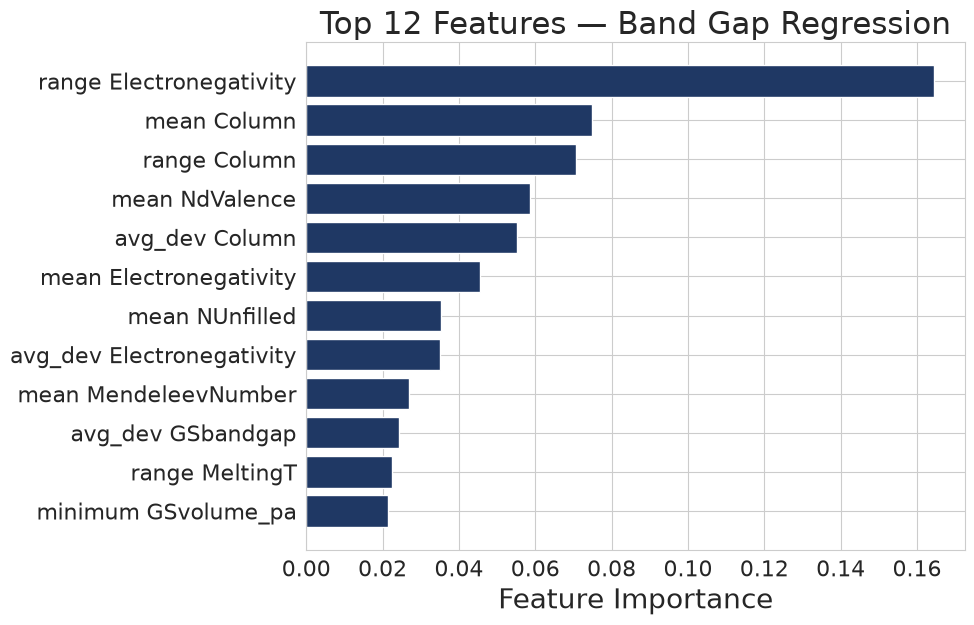

Top 3 most important features:
MagpieData range Electronegativity    0.164
MagpieData mean Column                0.075
MagpieData range Column               0.071
dtype: float64


In [10]:
importances = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=True)
top12 = importances.tail(12)
top12.index = [i.replace("MagpieData ", "") for i in top12.index]

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(top12.index, top12.values, color="#1F3864")
ax.set_xlabel("Feature Importance")
ax.set_title("Top 12 Features — Band Gap Regression")
plt.tight_layout()
plt.savefig("figures/fig_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 3 most important features:")
print(importances.sort_values(ascending=False).head(3).round(3))

## 10. Conclusions & Limitations

- A composition-only Random Forest model distinguishes Sn-Se-based metals from insulators with ~80% cross-validated accuracy, and predicts the band gap of insulating members with a mean error of ~0.36 eV — a useful, fast first-pass screen for candidate dopants/alloys, not a replacement for DFT or experiment.
- Electronegativity-related descriptors (especially the range of electronegativity across a compound's elements) dominate the model's predictions, consistent with known band-engineering mechanisms in IV-VI chalcogenides.
- **Limitation:** composition-only features can't distinguish polymorphs (e.g. SnSe's room-temperature orthorhombic phase vs. its high-temperature phase) — two compounds with the same formula but different structures get identical features. The dataset (~190 compounds) is also small relative to the 130+ features used, which the 5-fold cross-validation is meant to guard against but doesn't eliminate.

## 11. Individual Contributions

| Member | Contribution |
|---|---|
| Dr. Prashant Shahi | Chose topic and dataset, coordinated the group, built and ran the modeling notebook |
| Mrs. Akanksha | Sourced and queried the Materials Project dataset |
| Dr. Santosh Kumar | Cleaned the data and built the composition/feature pipeline |
| Mrs. Alfiya Mahmood | Wrote and formatted the report |
| Dr. Nagendra Kumar Singh | Built the slide deck and prepared the presentation |